In [1]:
import os
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import torch
import torch.nn as nn
import torchvision
from torchvision.transforms import v2
from torchvision import models
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision.transforms.functional import to_pil_image
from torchmetrics import MeanMetric, Accuracy
from torchmetrics import ConfusionMatrix, Accuracy, Precision, Recall, F1Score

In [2]:
device = "cuda" if torch.cuda.is_available() \
          else "mps" if torch.mps.is_available() \
          else "cpu"
print("Device:", device)

Device: cuda


In [3]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
DATA_DIR = "/kaggle/input/datasets/daphn3/dfuc2021/DFU"

train_csv = os.path.join(DATA_DIR, "DFUC2021_train", "train.csv")
train_image_dir = os.path.join(DATA_DIR, "DFUC2021_train", "images")
test_image_dir = os.path.join(DATA_DIR, "DFUC2021_test")

In [5]:
print("Train CSV:", os.path.exists(train_csv))
print("Train images:", os.path.exists(train_image_dir))
print("Test images:", os.path.exists(test_image_dir))

Train CSV: True
Train images: True
Test images: True


In [6]:
train_df = pd.read_csv(train_csv)

label_cols = [
    "none",
    "infection",
    "ischaemia",
    "both"
]

class_names = label_cols.copy()

labelled_df = train_df[
    train_df[label_cols].notna().any(axis=1)
].copy()

unlabelled_df = train_df[
    train_df[label_cols].isna().all(axis=1)
].copy()

labelled_df["label"] = (
    labelled_df[label_cols]
    .values
    .argmax(axis=1)
)

print("Labelled:", len(labelled_df))
print("Unlabelled:", len(unlabelled_df))

print(
    labelled_df["label"]
    .value_counts()
    .sort_index()
)

Labelled: 5955
Unlabelled: 3994
label
0    2552
1    2555
2     227
3     621
Name: count, dtype: int64


In [8]:
from sklearn.model_selection import train_test_split

train_split_df, val_df = train_test_split(
    labelled_df,
    test_size=0.10,
    random_state=seed,
    stratify=labelled_df["label"])

In [9]:
train_split_df, val_df = train_test_split(
    labelled_df,
    test_size=0.10,
    random_state=seed,
    stratify=labelled_df["label"]
)

train_split_df = train_split_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Training:", len(train_split_df))
print("Validation:", len(val_df))

print("\nTraining class distribution:")
print(
    train_split_df["label"]
    .value_counts()
    .sort_index()
)

Training: 5359
Validation: 596

Training class distribution:
label
0    2297
1    2299
2     204
3     559
Name: count, dtype: int64


In [10]:
train_transform = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),

    v2.RandomVerticalFlip(p=0.5),

    v2.RandomRotation(
        degrees=20
    ),

    v2.ToImage(),

    v2.ToDtype(
        torch.float32,
        scale=True
    ),

    v2.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [11]:
minority_transform = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),

    v2.RandomVerticalFlip(p=0.5),

    v2.RandomAffine(
        degrees=30,
        translate=(0.05, 0.05),
        scale=(0.90, 1.10),
        shear=(-10, 10)
    ),

    v2.ColorJitter(
        brightness=0.10,
        contrast=0.10,
        saturation=0.05
    ),

    v2.ToImage(),

    v2.ToDtype(
        torch.float32,
        scale=True
    ),

    v2.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [12]:
test_transform = v2.Compose([
    v2.ToImage(),

    v2.ToDtype(
        torch.float32,
        scale=True
    ),

    v2.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [13]:
genuine_train_df = train_split_df[
    ["image", "label"]
].copy()

genuine_train_df["transform_type"] = "standard"
genuine_train_df["source"] = "genuine"

print(genuine_train_df.shape)

(5359, 4)


In [14]:
ischaemia_genuine = train_split_df[
    train_split_df["label"] == 2
][["image", "label"]].copy()

print(
    "Genuine Ischaemia images:",
    len(ischaemia_genuine)
)

Genuine Ischaemia images: 204


In [15]:
ischaemia_augmented = pd.concat(
    [
        ischaemia_genuine.copy()
        for _ in range(8)
    ],
    ignore_index=True
)

ischaemia_augmented[
    "transform_type"
] = "minority"

ischaemia_augmented[
    "source"
] = "augmented_ischaemia"

print(
    "Additional Ischaemia instances:",
    len(ischaemia_augmented)
)

Additional Ischaemia instances: 1632


In [16]:
both_genuine = train_split_df[
    train_split_df["label"] == 3
][["image", "label"]].copy()

print(
    "Genuine Both images:",
    len(both_genuine)
)

Genuine Both images: 559


In [17]:
both_augmented = pd.concat(
    [
        both_genuine.copy()
        for _ in range(3)
    ],
    ignore_index=True
)

both_augmented[
    "transform_type"
] = "minority"

both_augmented[
    "source"
] = "augmented_both"

print(
    "Additional Both instances:",
    len(both_augmented)
)

Additional Both instances: 1677


In [18]:
train_aug_df = pd.concat(
    [
        genuine_train_df,
        ischaemia_augmented,
        both_augmented
    ],
    ignore_index=True
)

print(
    "Total training instances:",
    len(train_aug_df)
)

print("\nRows by source:")
print(
    train_aug_df["source"]
    .value_counts()
)

print("\nEffective class distribution:")
print(
    train_aug_df["label"]
    .value_counts()
    .sort_index()
)

Total training instances: 8668

Rows by source:
source
genuine                5359
augmented_both         1677
augmented_ischaemia    1632
Name: count, dtype: int64

Effective class distribution:
label
0    2297
1    2299
2    1836
3    2236
Name: count, dtype: int64


In [19]:
train_aug_df.to_csv(
    "/kaggle/working/augmentation_only_training_manifest.csv",
    index=False
)

In [20]:
overlap = set(
    train_aug_df["image"]
).intersection(
    set(val_df["image"])
)

print(
    "Validation overlap:",
    len(overlap)
)

assert len(overlap) == 0

Validation overlap: 0


In [21]:
class DFUAugmentationDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_dir,
        standard_transform,
        minority_transform
    ):

        self.dataframe = (
            dataframe
            .reset_index(drop=True)
        )

        self.image_dir = image_dir

        self.standard_transform = (
            standard_transform
        )

        self.minority_transform = (
            minority_transform
        )

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image_path = os.path.join(
            self.image_dir,
            row["image"]
        )

        image = Image.open(
            image_path
        ).convert("RGB")

        label = int(
            row["label"]
        )

        if (
            row["transform_type"]
            == "minority"
        ):

            image = self.minority_transform(
                image
            )

        else:

            image = self.standard_transform(
                image
            )

        return (
            image,
            torch.tensor(
                label,
                dtype=torch.long
            )
        )

In [22]:
class DFUDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_dir,
        transform=None
    ):

        self.dataframe = (
            dataframe
            .reset_index(drop=True)
        )

        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image_path = os.path.join(
            self.image_dir,
            row["image"]
        )

        image = Image.open(
            image_path
        ).convert("RGB")

        label = int(
            row["label"]
        )

        if self.transform:
            image = self.transform(
                image
            )

        return (
            image,
            torch.tensor(
                label,
                dtype=torch.long
            )
        )

In [23]:
BATCH_SIZE = 16

train_aug_dataset = DFUAugmentationDataset(
    train_aug_df,
    train_image_dir,
    standard_transform=train_transform,
    minority_transform=minority_transform
)

val_dataset = DFUDataset(
    val_df,
    train_image_dir,
    transform=test_transform
)

train_loader = DataLoader(
    train_aug_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(
    "Training instances:",
    len(train_aug_dataset)
)

print(
    "Validation images:",
    len(val_dataset)
)

Training instances: 8668
Validation images: 596


In [24]:
assert len(labelled_df) == 5955
assert len(train_split_df) == 5359
assert len(val_df) == 596

assert len(train_aug_df) == 8668
assert len(overlap) == 0

assert (
    train_aug_df[
        train_aug_df["source"]
        == "augmented_ischaemia"
    ]["label"] == 2
).all()

assert (
    train_aug_df[
        train_aug_df["source"]
        == "augmented_both"
    ]["label"] == 3
).all()

assert (
    train_aug_df["source"]
    == "pseudo_097"
).sum() == 0

print(
    "Everything looks correct — augmentation-only experiment ready."
)

Everything looks correct — augmentation-only experiment ready.


In [25]:
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [26]:
model = models.efficientnet_b3(
    weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1
)

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    4
)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 170MB/s] 


In [27]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

In [28]:
def train_one_epoch(
    model,
    dataloader
):

    losses = MeanMetric().to(device)

    acc = Accuracy(
        task="multiclass",
        num_classes=4
    ).to(device)

    model.train()

    for X, Y in tqdm(dataloader):

        X = X.to(device)
        Y = Y.to(device)

        preds = model(X)

        loss = criterion(
            preds,
            Y
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        predicted_classes = preds.argmax(
            dim=1
        )

        losses.update(
            loss,
            X.size(0)
        )

        acc.update(
            predicted_classes,
            Y
        )

    return (
        losses.compute().item(),
        acc.compute().item()
    )

In [29]:
def validation_one_epoch(
    model,
    dataloader
):

    losses = MeanMetric().to(device)

    acc = Accuracy(
        task="multiclass",
        num_classes=4
    ).to(device)

    model.eval()

    with torch.no_grad():

        for X, Y in tqdm(dataloader):

            X = X.to(device)
            Y = Y.to(device)

            preds = model(X)

            loss = criterion(
                preds,
                Y
            )

            predicted_classes = preds.argmax(
                dim=1
            )

            losses.update(
                loss,
                X.size(0)
            )

            acc.update(
                predicted_classes,
                Y
            )

    return (
        losses.compute().item(),
        acc.compute().item()
    )

In [30]:
history_aug_only = pd.DataFrame()

best_val_acc = 0.0
best_epoch = 0

epochs = 100

patience = 8
epochs_no_improve = 0

min_delta = 0.0001

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.1,
    patience=5
)

In [31]:
for i in range(epochs):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader
    )

    val_loss, val_acc = validation_one_epoch(
        model,
        val_loader
    )

    scheduler.step(
        val_acc
    )

    if (
        val_acc
        > best_val_acc + min_delta
    ):

        best_val_acc = val_acc
        best_epoch = i + 1
        epochs_no_improve = 0

        torch.save(
            model.state_dict(),
            "/kaggle/working/"
            "best_efficientnetb3_augmentation_only.pth"
        )

    else:

        epochs_no_improve += 1

    statistics = pd.DataFrame({
        "epoch":
            [i + 1],

        "train_loss":
            [train_loss],

        "train_acc":
            [train_acc],

        "val_loss":
            [val_loss],

        "val_acc":
            [val_acc],

        "learning_rate":
            [
                optimizer
                .param_groups[0]["lr"]
            ]
    })

    history_aug_only = pd.concat(
        [
            history_aug_only,
            statistics
        ],
        ignore_index=True
    )

    history_aug_only.to_csv(
        "/kaggle/working/"
        "history_efficientnetb3_augmentation_only.csv",
        index=False
    )

    print(
        statistics
        .to_dict(
            orient="records"
        )[0]
    )

    if (
        epochs_no_improve
        >= patience
    ):

        print(
            f"Early stopping at epoch {i + 1}"
        )

        break


print(
    "Best epoch:",
    best_epoch
)

print(
    "Best validation accuracy:",
    best_val_acc
)

100%|██████████| 38/38 [00:06<00:00,  5.84it/s]


{'epoch': 1, 'train_loss': 0.7024185061454773, 'train_acc': 0.6982002854347229, 'val_loss': 0.7279284000396729, 'val_acc': 0.6996644139289856, 'learning_rate': 0.001}


100%|██████████| 38/38 [00:02<00:00, 13.08it/s]


{'epoch': 2, 'train_loss': 0.5220090746879578, 'train_acc': 0.7840332388877869, 'val_loss': 0.6758838891983032, 'val_acc': 0.713087260723114, 'learning_rate': 0.001}


100%|██████████| 38/38 [00:03<00:00, 12.63it/s]


...

{'epoch': 70, 'train_loss': 0.020068446174263954, 'train_acc': 0.9922704100608826, 'val_loss': 0.3486458957195282, 'val_acc': 0.9161073565483093, 'learning_rate': 1e-05}


100%|██████████| 38/38 [00:02<00:00, 14.34it/s]


{'epoch': 71, 'train_loss': 0.0191382747143507, 'train_acc': 0.9944623708724976, 'val_loss': 0.33601444959640503, 'val_acc': 0.9211409687995911, 'learning_rate': 1e-05}


100%|██████████| 38/38 [00:02<00:00, 14.15it/s]

{'epoch': 72, 'train_loss': 0.01699625700712204, 'train_acc': 0.9946931004524231, 'val_loss': 0.35582855343818665, 'val_acc': 0.9211409687995911, 'learning_rate': 1e-05}
Early stopping at epoch 72
Best epoch: 64
Best validation accuracy: 0.9278523325920105


In [32]:
model.load_state_dict(
    torch.load(
        "/kaggle/working/"
        "best_efficientnetb3_augmentation_only.pth",
        map_location=device,
        weights_only=True
    )
)

model = model.to(device)
model.eval()

print(
    "Best augmentation-only model loaded."
)

Best augmentation-only model loaded.


In [33]:
y_true = []
y_pred = []
y_prob = []

model.eval()

with torch.inference_mode():

    for images, labels in tqdm(
        val_loader
    ):

        images = images.to(device)

        outputs = model(
            images
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        predictions = probabilities.argmax(
            dim=1
        )

        y_true.extend(
            labels.numpy()
        )

        y_pred.extend(
            predictions
            .cpu()
            .numpy()
        )

        y_prob.extend(
            probabilities
            .cpu()
            .numpy()
        )

100%|██████████| 38/38 [00:02<00:00, 14.10it/s]


In [34]:
y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

In [36]:
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report
)

In [37]:
macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

per_class_f1 = f1_score(
    y_true,
    y_pred,
    average=None
)

macro_precision = precision_score(
    y_true,
    y_pred,
    average="macro"
)

macro_recall = recall_score(
    y_true,
    y_pred,
    average="macro"
)

micro_f1 = f1_score(
    y_true,
    y_pred,
    average="micro"
)

y_true_onehot = np.eye(4)[
    y_true
]

micro_auc = roc_auc_score(
    y_true_onehot,
    y_prob,
    average="micro",
    multi_class="ovr"
)

macro_auc = roc_auc_score(
    y_true_onehot,
    y_prob,
    average="macro",
    multi_class="ovr"
)

In [38]:
print("Macro F1:", macro_f1)

for name, score in zip(
    class_names,
    per_class_f1
):
    print(
        f"{name} F1:",
        score
    )

print(
    "Macro Precision:",
    macro_precision
)

print(
    "Macro Recall:",
    macro_recall
)

print(
    "Micro F1:",
    micro_f1
)

print(
    "Micro AUC:",
    micro_auc
)

print(
    "Macro AUC:",
    macro_auc
)

Macro F1: 0.9468881966594929
none F1: 0.9197651663405088
infection F1: 0.9212598425196851
ischaemia F1: 0.9777777777777777
both F1: 0.96875
Macro Precision: 0.9464835294913421
Macro Recall: 0.9480382166453538
Micro F1: 0.9278523489932886
Micro AUC: 0.9888293320120716
Macro AUC: 0.9875298062136628


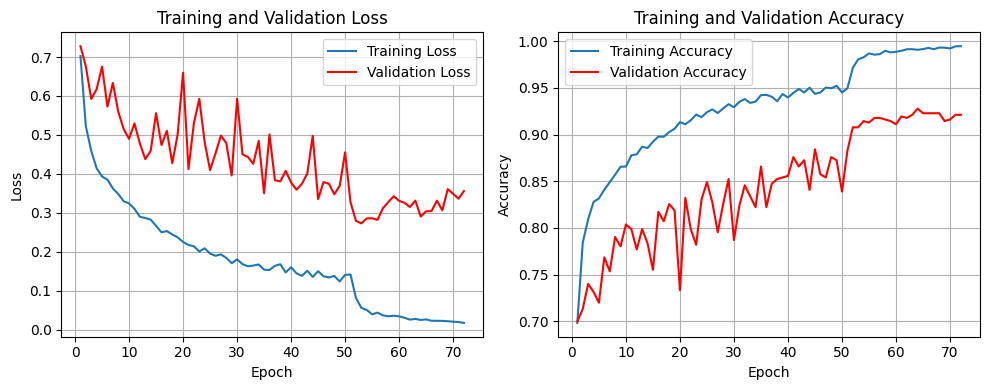

In [39]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)

plt.plot(
    history_aug_only["epoch"],
    history_aug_only["train_loss"],
    label="Training Loss"
)

plt.plot(
    history_aug_only["epoch"],
    history_aug_only["val_loss"],
    label="Validation Loss",
    color="red"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training and Validation Loss"
)

plt.legend()
plt.grid(True)


plt.subplot(1, 2, 2)

plt.plot(
    history_aug_only["epoch"],
    history_aug_only["train_acc"],
    label="Training Accuracy"
)

plt.plot(
    history_aug_only["epoch"],
    history_aug_only["val_acc"],
    label="Validation Accuracy",
    color="red"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Training and Validation Accuracy"
)

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [40]:
model = models.efficientnet_b3(weights=None)

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    4
)

model = model.to(device)

model.load_state_dict(
    torch.load(
        "/kaggle/working/best_efficientnetb3_augmentation_only.pth",
        map_location=device,
        weights_only=True
    )
)

model.eval()

print("Best augmentation-only model loaded.")

Best augmentation-only model loaded.


In [41]:
test_transform = v2.Compose([
    v2.ToImage(),

    v2.ToDtype(
        torch.float32,
        scale=True
    ),

    v2.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [42]:
class DFUTestDataset(Dataset):

    def __init__(
        self,
        image_dir,
        transform=None
    ):

        self.image_dir = image_dir
        self.transform = transform

        self.image_files = sorted([
            f for f in os.listdir(image_dir)
            if f.lower().endswith(
                (".jpg", ".jpeg", ".png")
            )
        ])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):

        filename = self.image_files[idx]

        image_path = os.path.join(
            self.image_dir,
            filename
        )

        image = Image.open(
            image_path
        ).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, filename

In [43]:
test_dataset = DFUTestDataset(
    test_image_dir,
    transform=test_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

print(
    "Test images:",
    len(test_dataset)
)

Test images: 5734


In [44]:
all_filenames = []
all_probabilities = []

model.eval()

with torch.inference_mode():

    for images, filenames in tqdm(
        test_loader
    ):

        images = images.to(device)

        outputs = model(
            images
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )

        all_filenames.extend(
            filenames
        )

100%|██████████| 359/359 [01:06<00:00,  5.39it/s]


In [45]:
probabilities_array = np.array(
    all_probabilities
)

augmentation_only_submission = pd.DataFrame({
    "image": all_filenames,
    "none": probabilities_array[:, 0],
    "infection": probabilities_array[:, 1],
    "ischaemia": probabilities_array[:, 2],
    "both": probabilities_array[:, 3]
})

augmentation_only_submission.head()

,image,none,infection,ischaemia,both
0,501000.jpg,0.000001,0.998649,1.657913e-09,1.349811e-03
1,501001.jpg,0.000068,0.000051,7.836031e-01,2.162779e-01
2,501002.jpg,0.682987,0.317000,1.103916e-05,1.903925e-06
3,501003.jpg,0.024639,0.975361,6.553078e-08,6.166738e-09
4,501004.jpg,0.000642,0.020653,8.873839e-01,9.132116e-02


In [46]:
print(
    "Shape:",
    augmentation_only_submission.shape
)

print(
    "Columns:",
    augmentation_only_submission.columns.tolist()
)

print(
    "Missing values:",
    augmentation_only_submission
    .isna()
    .sum()
    .sum()
)

print(
    "Duplicate images:",
    augmentation_only_submission[
        "image"
    ]
    .duplicated()
    .sum()
)

print(
    "Unique images:",
    augmentation_only_submission[
        "image"
    ]
    .nunique()
)

Shape: (5734, 5)
Columns: ['image', 'none', 'infection', 'ischaemia', 'both']
Missing values: 0
Duplicate images: 0
Unique images: 5734


In [47]:
prob_cols = [
    "none",
    "infection",
    "ischaemia",
    "both"
]

row_sums = augmentation_only_submission[
    prob_cols
].sum(axis=1)

print(
    row_sums.describe()
)

count    5.734000e+03
mean     1.000000e+00
std      5.460178e-08
min      9.999998e-01
25%      9.999999e-01
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64


In [48]:
print(
    augmentation_only_submission[
        prob_cols
    ].min()
)

print(
    augmentation_only_submission[
        prob_cols
    ].max()
)

none         2.351907e-33
infection    1.888324e-28
ischaemia    4.350592e-21
both         9.354875e-17
dtype: float32
none         1.0
infection    1.0
ischaemia    1.0
both         1.0
dtype: float32


In [49]:
submission_path = (
    "/kaggle/working/"
    "efficientnetb3_augmentation_only_submission.csv"
)

augmentation_only_submission.to_csv(
    submission_path,
    index=False
)

print(
    "Saved:",
    submission_path
)

Saved: /kaggle/working/efficientnetb3_augmentation_only_submission.csv


In [50]:
check_submission = pd.read_csv(
    submission_path
)

print(
    check_submission.shape
)

print(
    check_submission.columns.tolist()
)

print(
    check_submission.head()
)

(5734, 5)
['image', 'none', 'infection', 'ischaemia', 'both']
        image      none  infection     ischaemia          both
0  501000.jpg  0.000001   0.998649  1.657913e-09  1.349811e-03
1  501001.jpg  0.000068   0.000051  7.836031e-01  2.162778e-01
2  501002.jpg  0.682987   0.317000  1.103916e-05  1.903925e-06
3  501003.jpg  0.024639   0.975361  6.553078e-08  6.166738e-09
4  501004.jpg  0.000642   0.020653  8.873839e-01  9.132116e-02
